Importing libraries

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from sklearn.metrics import mean_absolute_error

Uploading the dataset and processing the data

In [3]:
# loading the csv data to a Pandas DataFrame
gold_data = pd.read_csv('/content/gld_price_data.csv')

In [19]:
# print first 5 rows in the dataframe
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [20]:
# print first 5 rows in the dataframe
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [4]:
# getting some basic informations about the data
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [5]:
# checking the number of missing values
gold_data.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [6]:
# getting the statistical measures of the data
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [15]:
correlation = gold_data.corr(numeric_only=True)

Constructing a heatmap to understand the correlatiom


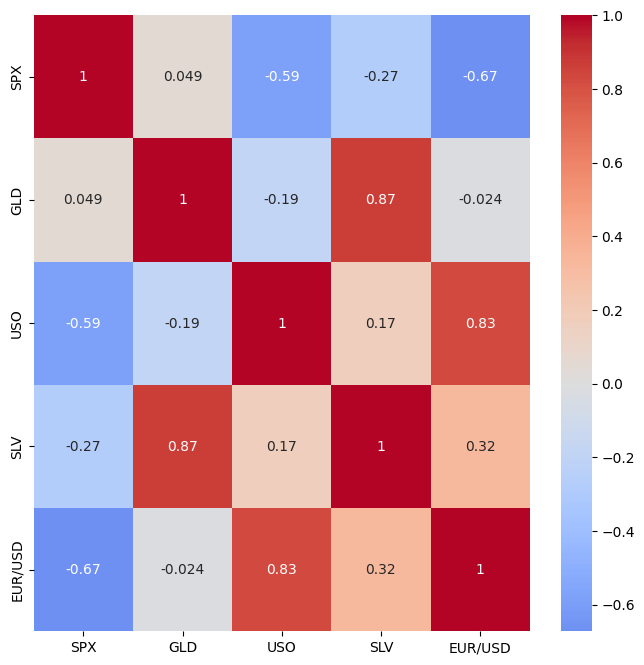

In [16]:
plt.figure(figsize=(8,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.show()

In [17]:
# correlation values of GLD
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


/tmp/ipykernel_4271/563101706.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gold_data['GLD'],color='green')


<Axes: xlabel='GLD', ylabel='Density'>

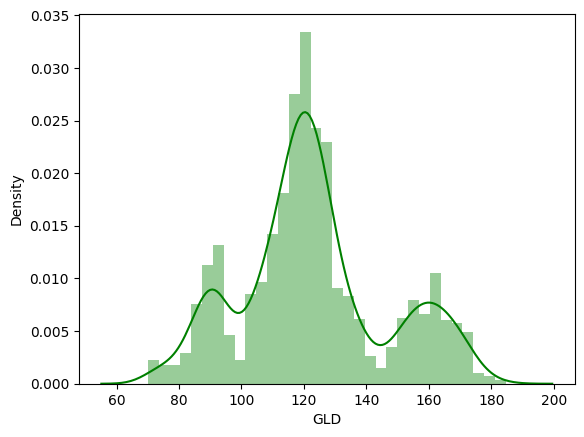

In [18]:
# checking the distribution of the GLD Price
sns.distplot(gold_data['GLD'],color='green')

Splitting the Features and Target


In [22]:
#Splits data into inputs(X) and target(Y = GLD)
X = gold_data.drop(['Date','GLD'],axis=1)
Y = gold_data['GLD']

In [23]:
print(X.shape)
print(Y.shape)
print(X.isnull().sum())
print(Y.isnull().sum())

(2290, 4)
(2290,)
SPX        0
USO        0
SLV        0
EUR/USD    0
dtype: int64
0


In [24]:
print(X)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [25]:
print(Y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


Splitting into Training data and Test Data

In [27]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=2)

Model Training:Random Forest Regressor

In [28]:
regressor = RandomForestRegressor(n_estimators=100)

In [29]:
# training the model
regressor.fit(X_train,Y_train)

RandomForestRegressor()

Model Evaluation

In [30]:
# prediction on Test Data
test_data_prediction = regressor.predict(X_test)

In [31]:
print(test_data_prediction)

[168.49619922  81.74989988 116.21190042 127.70460094 120.65650119
 154.69319795 150.60989798 126.09100011 117.66189894 125.90450092
 116.51690114 171.87780056 141.24239842 167.8372984  115.31720028
 117.87300065 138.82330292 169.88600121 159.82190281 161.20039939
 155.09230022 124.86690011 175.8955996  157.67070345 125.18940037
  93.84480006  78.40219987 120.90590025 119.16269962 167.54450012
  88.27160048 125.15129974  91.13950087 117.71770047 121.01519933
 136.02030049 115.65400146 114.74580078 149.16529892 107.51190126
 104.51330232  87.33619828 126.50210053 117.85530033 154.61229875
 119.58950007 108.33699998 108.00329838  93.28400048 126.89289844
  75.08840062 113.57509894 121.30559971 111.24779949 118.79909898
 120.61379939 158.8894013  168.88590136 146.88049651  86.04819869
  94.33320042  86.77059877  90.8658999  118.85500102 126.44040047
 127.3450002  169.6082009  122.22399904 117.12669932  98.28690023
 168.16680192 142.84289877 132.59670285 121.24720181 120.72209957
 119.78910

In [32]:
print(test_data_prediction[:5]) #First 5 predicted values
print(Y_test[:5]) #First 5 actual values

[168.49619922  81.74989988 116.21190042 127.70460094 120.65650119]
903     168.020004
129      81.230003
1787    112.320000
1913    127.589996
2048    119.620003
Name: GLD, dtype: float64


In [33]:
#calculates how well your model’s predictions match the actual values.
r2 = r2_score(Y_test, test_data_prediction)
print("R2 Score:", r2)

R2 Score: 0.989315333334286


R^2 score is 98.93, which means that the model explains ~99% of the variation in gold prices

In [40]:
#Calculates the average absolute difference between: actual values (Y_test) and predicted values (test_data_prediction)
mae = mean_absolute_error(Y_test, test_data_prediction)
print("MAE:", mae)

MAE: 1.329057920262006


model achieved an MAE of 1.33, indicating very low prediction error relative to the price range, along with an R² of 0.989

In [45]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(Y_test, test_data_prediction))
print("RMSE:", rmse)

RMSE: 2.373933021271026


Model achieved an R² of 0.989 with low MAE (1.33) and RMSE (2.37), indicating high accuracy and minimal prediction variance.

In [46]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(regressor, X, Y, cv=5)

print("Scores:", scores)
print("Average:", scores.mean())

Scores: [-2.70298084  0.5341619   0.87054488  0.24733135 -0.46427922]
Average: -0.3030443864311445


Standard cross-validation performed poorly due to the time-dependent nature of the data. Using TimeSeriesSplit ensures realistic evaluation by preserving temporal order.

In [56]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
tscv = TimeSeriesSplit(n_splits=5)
scores = cross_val_score(regressor, X, Y, cv=tscv)
print("TimeSeries CV Scores:", scores)
print("Average:", scores.mean())

TimeSeries CV Scores: [0.99554089 0.99440874 0.98767319 0.99319379 0.99242197]
Average: 0.9926477180270838


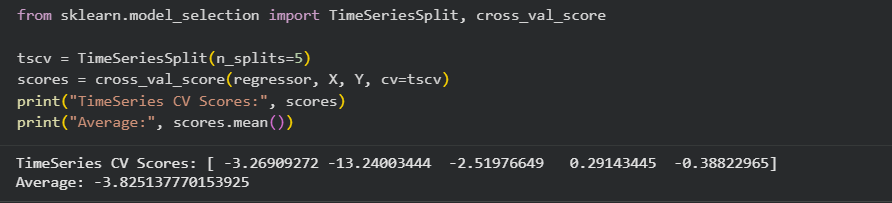


Earlier output was poor because the model didn’t have time-based features, so it couldn’t learn patterns over time ,but after adding lag and rolling features, performance improved drastically.

In [53]:
#Creates lag and rolling features from past gold prices and removes missing values.
gold_data['lag_1'] = gold_data['GLD'].shift(1)
gold_data['lag_2'] = gold_data['GLD'].shift(2)

gold_data['rolling_mean_5'] = gold_data['GLD'].rolling(5).mean()
gold_data['rolling_std_5'] = gold_data['GLD'].rolling(5).std()

gold_data = gold_data.dropna()

In [52]:
#Sorts the dataset by date to maintain correct time order.
gold_data = gold_data.sort_values('Date')

In [50]:
#Separates features (X) and target (Y = GLD) for model training.
X = gold_data.drop(['Date','GLD'], axis=1)
Y = gold_data['GLD']

In [51]:
#Evaluates the model using time-based cross-validation and prints performance scores.
scores = cross_val_score(regressor, X, Y, cv=tscv)
print(scores)
print(scores.mean())

[0.99550317 0.99466238 0.98733727 0.99368857 0.99244621]
0.9927275195383691


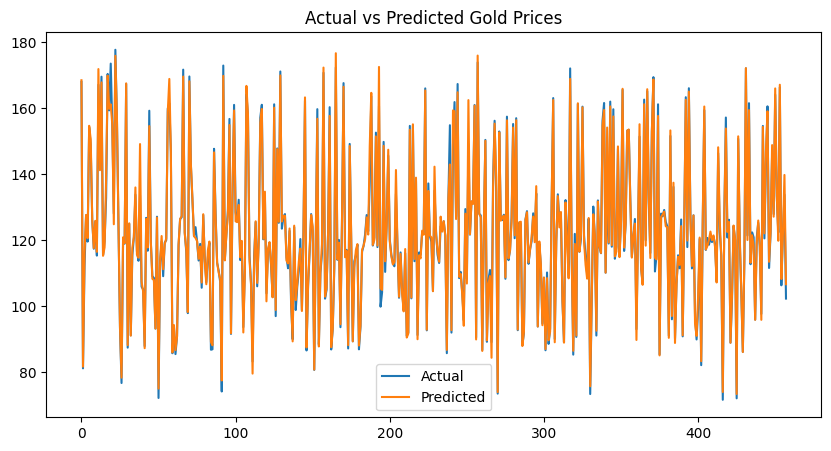

In [37]:
plt.figure(figsize=(10,5))
plt.plot(Y_test.values, label='Actual')
plt.plot(test_data_prediction, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Gold Prices")
plt.show()

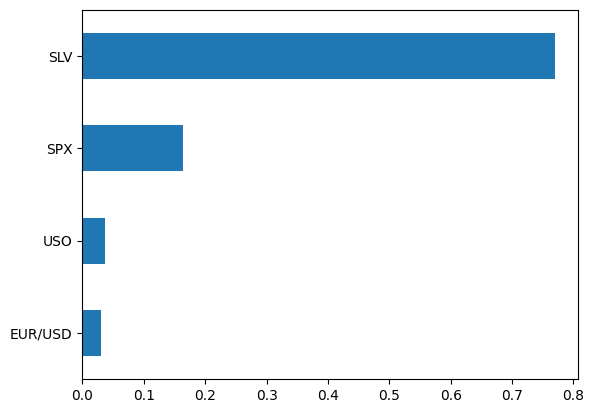

In [41]:
#Creates and plots a chart showing which features are most important for the model’s predictions.
feature_importance = pd.Series(regressor.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind='barh')
plt.show()

In [57]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=2)
}

for name, model in models.items():
    model.fit(X_train, Y_train)
    score = model.score(X_test, Y_test)
    print(f"{name}: {score}")

Linear Regression: 0.8657886565869237
Decision Tree: 0.984037082324652
Random Forest: 0.9884562581856317


In [43]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor()
gbr.fit(X_train, Y_train)

print("Gradient Boosting R2:", gbr.score(X_test, Y_test))

Gradient Boosting R2: 0.976489728096999


Compared multiple regression models and found that Random Forest performed best with an R² score of ~0.988, indicating strong predictive performance on unseen data.